<a href="https://colab.research.google.com/github/jatin-reddy/gpt2/blob/main/Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
import math, copy, time
import matplotlib.pyplot as plt
import seaborn

Let us assume
- Sequence length = T
- Model dimension = d_model
- Number of heads = h
- Per-head dimension = d_k = d_v = d_model / h

### Self-Attention
For each word, we create a Query vector, a Key vector, and a Value vector
- The first step is to calculate the Query, Key, and Value matrices. We do that by packing our embeddings into a matrix X, and multiplying it by the weight matrices we’ve trained (WQ, WK, WV).

Input X - T tokens and each token is is d_model dimensional vector.
- dim(X) = T*d_model

Projection matrices - W_Q, W_K, W_V - Learnable (We use learned linear projections to project the queries, keys and values).
- dim(W_Q) = d_model*dk
- dim(W_K) = d_model*dk
- dim(W_V) = d_model*dv

Then,
- Q = XW_Q = dim(T*dk)
- K = XW_K = dim(T*dk)
- V = XW_V = dim(T*dv)

And in the original paper:
dk = dv = d_model/h

Now read https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html
linear => y=xAT+b
.

In [ ]:
d_model = 512
h = 8
#d_k = d_model/h # 64.0
#print(type(d_k))
d_k = int(d_model/h)
d_v = int(d_model/h)
T = 10
X = torch.Tensor(T, d_model)
print(X.shape)

torch.Size([10, 512])


In [ ]:
# Self Attention Block
Wq = nn.Linear(d_model, d_k, bias=False)
Wk = nn.Linear(d_model, d_k, bias=False)
Wv = nn.Linear(d_model, d_v, bias=False)

Q = Wq(X)
K = Wk(X)
V = Wv(X)


print(Q.shape)
print(K.shape)
print(V.shape)

torch.Size([10, 64])
torch.Size([10, 64])
torch.Size([10, 64])


In [ ]:
#https://docs.pytorch.org/docs/stable/generated/torch.matmul.html
#https://docs.pytorch.org/docs/stable/generated/torch.transpose.html#torch.transpose
score = torch.matmul(Q, torch.transpose(K, 0, 1))
score = score / math.sqrt(d_k)
print(score.shape) # T*T
# scores = Q @ Kᵀ / √d_k

torch.Size([10, 10])


In [ ]:
softmax_score = nn.Softmax(dim=-1)
Z = softmax_score(score)
Z = torch.matmul(Z, V)
print(Z.shape)

torch.Size([10, 64])


### Casual Self Attention / Masking
Masking is to prevent later words from influencing the context of other words. The idea set the values of the self attention scores of these tokens to 0. (Lower triangular matrix so to speak). In other words, Token i must not attend to tokens j > i (future tokens).

So to do that, we set the elements in the lower triangle of the matrix to -inf. Thus, softmax operation (i.e., e^-inf = 0) results in the required lower triangular matrix.

https://docs.pytorch.org/docs/stable/generated/torch.tril.html
https://docs.pytorch.org/docs/stable/generated/torch.Tensor.masked_fill_.html

In [ ]:
T = 10
tril = torch.tril(torch.ones(T,T))
score_masked = score.masked_fill(tril == 0, float('-inf'))
score_masked

tensor([[-8.8730e+35,        -inf,        -inf,        -inf,        -inf,
                -inf,        -inf,        -inf,        -inf,        -inf],
        [-1.3426e-19, -0.0000e+00,        -inf,        -inf,        -inf,
                -inf,        -inf,        -inf,        -inf,        -inf],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,        -inf,        -inf,
                -inf,        -inf,        -inf,        -inf,        -inf],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,        -inf,
                -inf,        -inf,        -inf,        -inf,        -inf],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
                -inf,        -inf,        -inf,        -inf,        -inf],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,        -inf,        -inf,        -inf,        -inf],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+0

In [ ]:
score_masked = softmax_score(score_masked)
print(score_masked.shape)
Z_masked = torch.matmul(score_masked, V)
print(Z_masked.shape)

torch.Size([10, 10])
torch.Size([10, 64])


In [ ]:
# let's move all of this to a function
def self_attention(X, masked=False):
  T = X.shape[0]
  d_model = X.shape[1]
  h = 8
  d_k = int(d_model/h)
  d_v = int(d_model/h)

  # Self Attention Block
  Wq = nn.Linear(d_model, d_k, bias=False)
  Wk = nn.Linear(d_model, d_k, bias=False)
  Wv = nn.Linear(d_model, d_v, bias=False)

  Q = Wq(X)
  K = Wk(X)
  V = Wv(X)

  score = torch.matmul(Q, torch.transpose(K, 0, 1))
  score = score / math.sqrt(d_k)
  softmax_score = nn.Softmax(dim=-1)


  if masked:
    tril = torch.tril(torch.ones(T,T))
    score = score.masked_fill(tril == 0, float('-inf'))

  weights = softmax_score(score)
  Z = torch.matmul(weights, V)
  return Z




```
def self_attention(...):
    Wq = nn.Linear(...)
```
This means: New random weights every function call and so nothing is trainable.
So, we need to move to a class.

In [ ]:
class SelfAttention(nn.Module):
  def __init__(self, d_model, h):
    super().__init__()
    self.d_model = d_model
    self.h = h
    self.d_k = int(d_model/h)
    self.d_v = int(d_model/h)

    self.Wq = nn.Linear(self.d_model, self.d_k, bias=False)
    self.Wk = nn.Linear(self.d_model, self.d_k, bias=False)
    self.Wv = nn.Linear(self.d_model, self.d_v, bias=False)
    self.softmax = nn.Softmax(dim=-1)

  def forward (self, X, masked):
    T = X.shape[0]
    Q = self.Wq(X)
    K = self.Wk(X)
    V = self.Wv(X)

    scores = Q @ K.transpose(0, 1)
    scores = scores / math.sqrt(self.d_k)

    if masked:
      tril = torch.tril(torch.ones(T,T, device=X.device))
      scores = scores.masked_fill(tril == 0, float('-inf'))

    weights = self.softmax(scores)
    Z = weights @ V
    return Z


The paper further refined the self-attention layer by adding a mechanism called “multi-headed” attention.

Motivation: Language often needs multiple simultaneous views:
- syntactic (subject–verb)
- semantic (coreference like “it”)
- positional
- long-range vs local

A single dot-product attention struggles to encode all of that at once.
- With multi-headed attention we have not only one, but multiple sets of Query/Key/Value weight matrices (the Transformer uses eight attention heads, so we end up with eight sets for each encoder/decoder).
- Each of these sets is randomly initialized.
- Then, after training, each set is used to project the input embeddings (or vectors from lower encoders/decoders) into a different representation subspace.
- If we do the same self-attention calculation we outlined above, just eight different times with different weight matrices, we end up with eight different Z matrices

This leaves us with a bit of a challenge. The feed-forward layer is not expecting eight matrices – it’s expecting a single matrix (a vector for each word). So we need a way to condense these eight down into a single matrix.

How do we do that? We concat the matrices then multiply them by an additional weights matrix WO. The result would be the Z matrix that captures information
from all the attention heads. We can send this forward to the FFNN

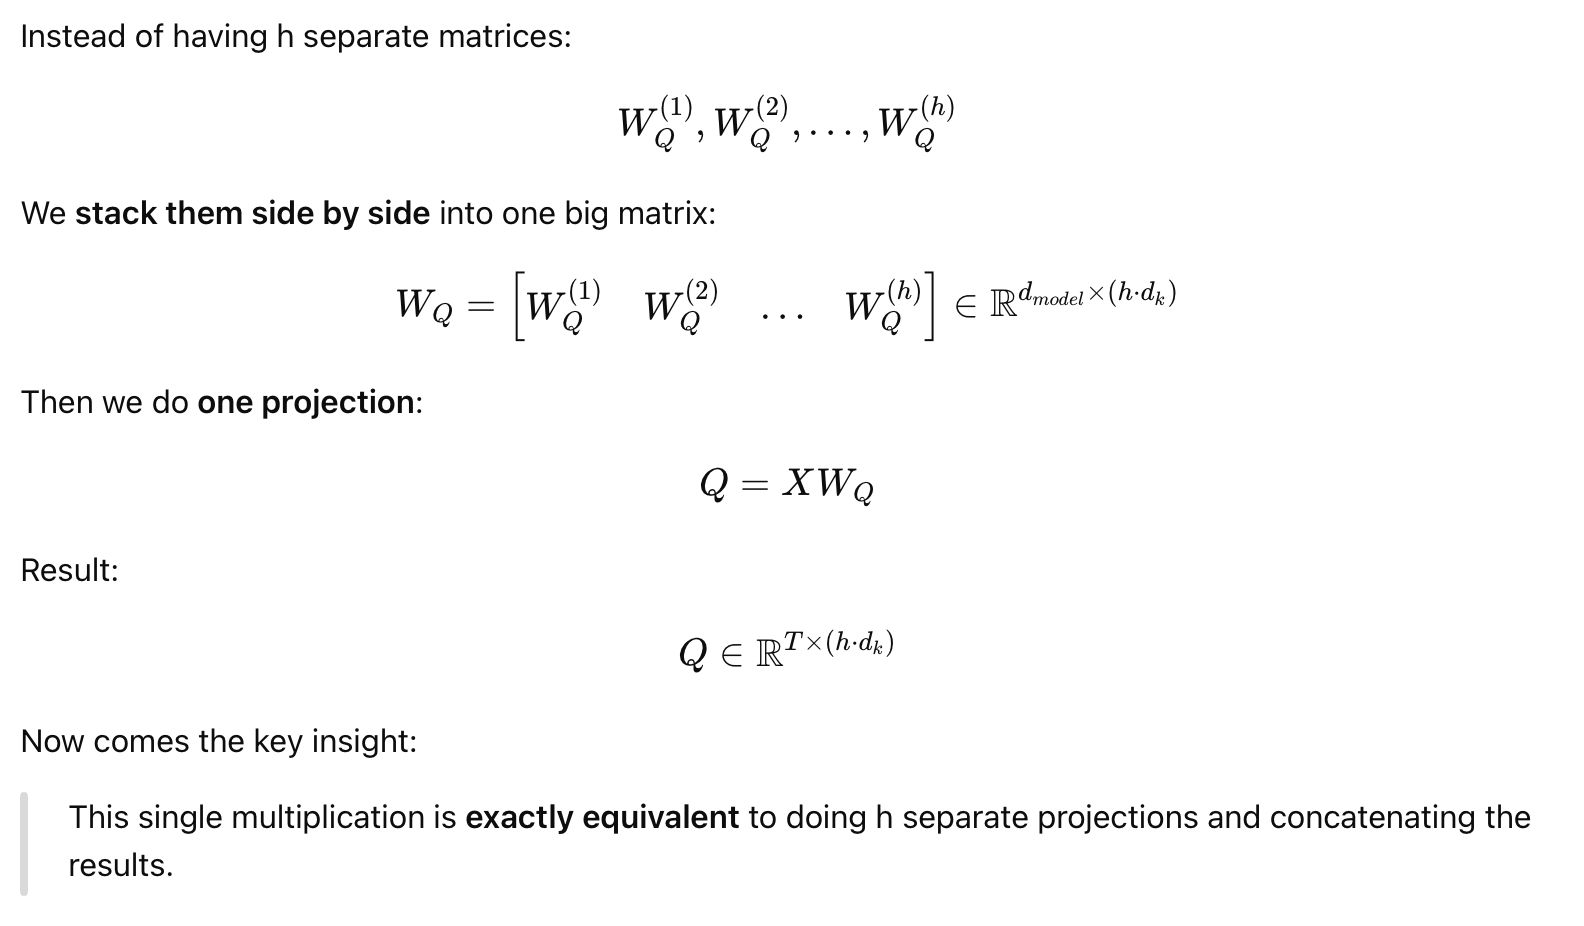

In [ ]:
# Project once and then reshape
class MultiHeadSelfAttention(nn.Module):
  def __init__(self, d_model, h):
    super().__init__()
    self.d_model = d_model
    self.h = h
    self.d_k = d_model // h
    self.d_v = d_model // h

    self.Wq = nn.Linear(self.d_model, self.d_model, bias=False) #d_model = h*d_k
    self.Wk = nn.Linear(self.d_model, self.d_model, bias=False) #d_model = h*d_k
    self.Wv = nn.Linear(self.d_model, self.d_model, bias=False) #d_model = h*d_v
    self.Wo = nn.Linear(self.d_model, self.d_model, bias=False) #d_model = h*d_k

    self.softmax = nn.Softmax(dim=-1)

  def forward (self, X, masked):
    T = X.shape[0]
    Q = self.Wq(X)
    K = self.Wk(X)
    V = self.Wv(X)

    # Reshape (T, h*d_k) to (T, h, d_k)  then transpose it to (h, T, d_k)
    Q = Q.torch.reshape(T, self.h, self.d_k).transpose(0, 1)
    K = K.torch.reshape(T, self.h, self.d_k).transpose(0, 1)
    V = V.torch.reshape(T, self.h, self.d_v).transpose(0, 1)

    scores = Q @ K.transpose(-2, -1)        # -2,-1 refers to T,T in (h, T, T)
    scores = scores / math.sqrt(self.d_k)

    if masked:
      tril = torch.tril(torch.ones(T,T, device=X.device))
      scores = scores.masked_fill(tril == 0, float('-inf'))
      # Pytorch broadcasts automatically across heads

    weights = self.softmax(scores)
    Z = weights @ V # (h, T, d_k)

    # Transpose back to (T, h, d_k) and reshape to (T, h*d_k)
    Z = Z.transpose(0,1).reshape(T, self.d_model) #(T, h*d_k)

    output = self.Wo(Z)
    return output



### Residual Connections
